In [77]:
# %% [markdown]
# # PTQ Results — Deep Visualization Suite
# Post-Training Quantization analysis across 7 backends.
# White theme, publication-quality plots.

# %% — Setup & Data
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings("ignore")

# ── White theme ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "monospace",
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.edgecolor":     "#CCCCCC",
    "axes.labelcolor":    "#333333",
    "axes.grid":          True,
    "grid.color":         "#EEEEEE",
    "grid.linestyle":     "--",
    "grid.alpha":         0.7,
    "xtick.color":        "#555555",
    "ytick.color":        "#555555",
    "text.color":         "#222222",
    "axes.titlecolor":    "#111111",
    "axes.titlesize":     13,
    "axes.titleweight":   "bold",
    "axes.labelsize":     11,
    "figure.dpi":         130,
    "savefig.dpi":        150,
    "savefig.bbox":       "tight",
    "savefig.facecolor":  "white",
})

# ── Baseline ──────────────────────────────────────────────────────────────────
BASELINE_ACC  = 0.932
BASELINE_CPU  = 887.9295   # ms
BASELINE_DISK = 90.0509    # MB

# ── Results (baseline first, then quantized backends) ─────────────────────────
results = [
    dict(backend="FP32 baseline",    observer="—  (no quantization)",
         acc=0.9320, drop=0.0000,  disk=90.0509, cpu=887.9295, compr=1.000),
    dict(backend="dynamic",          observer="per_channel_affine",
         acc=0.9319, drop=0.0001,  disk=89.9929, cpu=1394.77,  compr=1.0006),
    dict(backend="static_fx",        observer="minmax",
         acc=0.9329, drop=-0.0009, disk=22.9897, cpu=501.55,   compr=3.917),
    dict(backend="static_fx",        observer="moving_avg",
         acc=0.9316, drop=0.0004,  disk=22.9897, cpu=457.75,   compr=3.917),
    dict(backend="static_fx",        observer="histogram",
         acc=0.9315, drop=0.0005,  disk=22.9897, cpu=226.92,   compr=3.917),
    dict(backend="static_fx",        observer="percentile",
         acc=0.9321, drop=-0.0001, disk=22.9897, cpu=371.77,   compr=3.917),
    dict(backend="fx_static_x86",    observer="default(x86)",
         acc=0.9321, drop=-0.0001, disk=22.9897, cpu=256.39,   compr=3.917),
    dict(backend="fx_static_fbgemm", observer="default(fbgemm)",
         acc=0.9321, drop=-0.0001, disk=22.9897, cpu=259.50,   compr=3.917),
]

# ── Derived arrays ────────────────────────────────────────────────────────────
labels   = ["FP32\nbaseline", "Dynamic\n(Linear)", "Static-FX\nminmax",
            "Static-FX\nmoving_avg", "Static-FX\nhistogram",
            "Static-FX\npercentile", "FX-x86\n(default)", "FX-fbgemm\n(default)"]
accs     = [r["acc"]   for r in results]
drops    = [r["drop"]  for r in results]
disks    = [r["disk"]  for r in results]
cpu_ms   = [r["cpu"]   for r in results]
comprs   = [r["compr"] for r in results]
speedups = [BASELINE_CPU / c for c in cpu_ms]

# ── Colour palette — gray for baseline, then 7 distinct colors ────────────────
COLORS    = ["#6B7280","#3B82F6","#F97316","#FB923C","#FDBA74","#FCD34D","#10B981","#6366F1"]
BAR_ALPHA = 0.88

print("✓ Setup complete — FP32 baseline + 7 quantized backends loaded")
print(f"  Baseline: acc={BASELINE_ACC}, cpu={BASELINE_CPU:.1f} ms, disk={BASELINE_DISK:.1f} MB")

✓ Setup complete — FP32 baseline + 7 quantized backends loaded
  Baseline: acc=0.932, cpu=887.9 ms, disk=90.1 MB


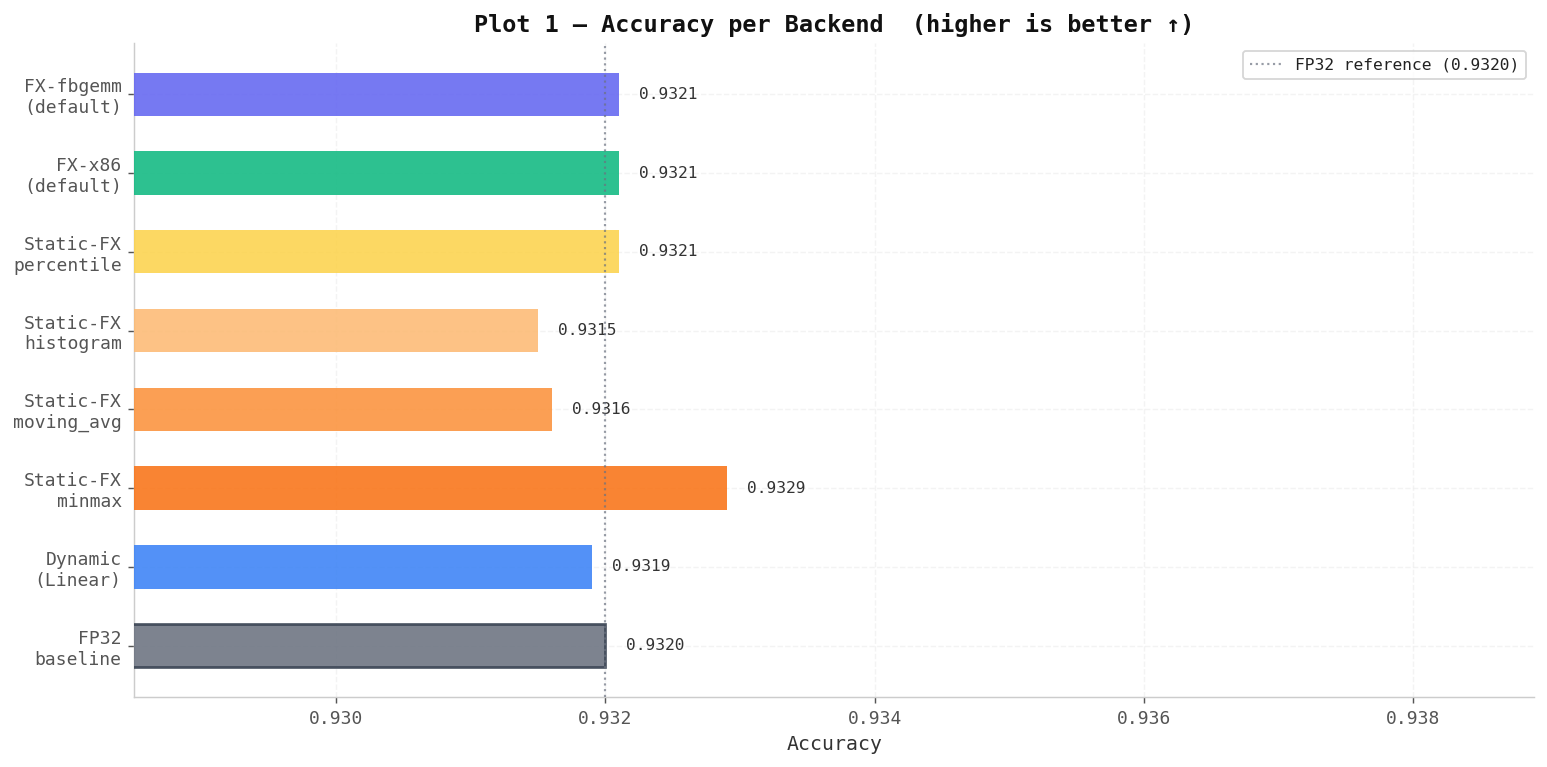

✓ Plot 1 saved → plot1_accuracy.png


In [78]:
# %% — Plot 1: Accuracy per Backend
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(labels, accs, color=COLORS, alpha=BAR_ALPHA, height=0.55, zorder=3)

# Highlight the baseline bar with a thicker edge
bars[0].set_edgecolor("#374151")
bars[0].set_linewidth(1.5)

# Subtle reference line at FP32 accuracy
ax.axvline(BASELINE_ACC, color="#6B7280", lw=1.2, ls=":", zorder=4, alpha=0.7,
           label=f"FP32 reference ({BASELINE_ACC:.4f})")

for bar, acc in zip(bars, accs):
    ax.text(acc + 0.00015, bar.get_y() + bar.get_height() / 2,
            f"{acc:.4f}", va="center", ha="left", fontsize=9, color="#333")

ax.set_xlabel("Accuracy")
ax.set_xlim(min(accs) - 0.003, max(accs) + 0.006)
ax.set_title("Plot 1 — Accuracy per Backend  (higher is better ↑)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("__1__PTQ_plots/plot1_accuracy.png")
plt.show()
print("✓ Plot 1 saved → plot1_accuracy.png")

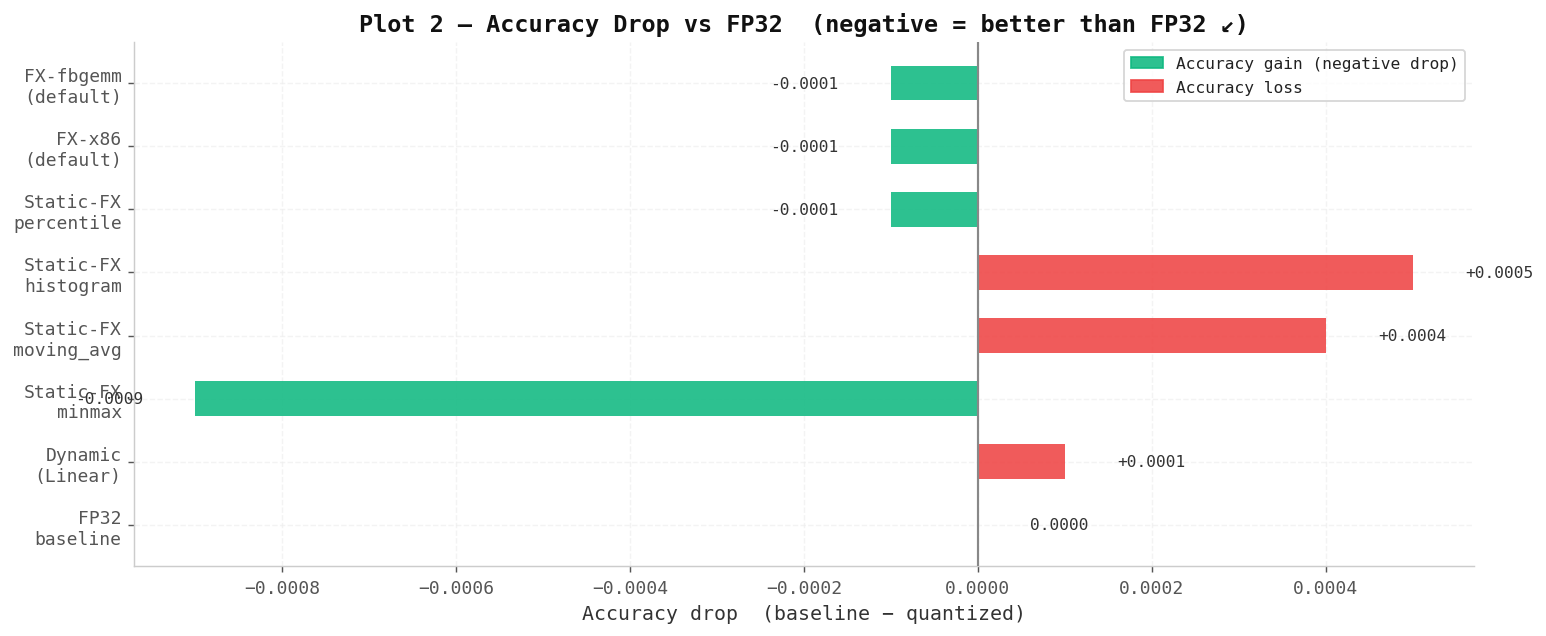

✓ Plot 2 saved → plot2_accuracy_drop.png


In [79]:
# %% — Plot 2: Accuracy Drop (diverging bar)
fig, ax = plt.subplots(figsize=(12, 5))

drop_colors = ["#10B981" if d <= 0 else "#EF4444" for d in drops]
bars = ax.barh(labels, drops, color=drop_colors, alpha=BAR_ALPHA, height=0.55, zorder=3)
ax.axvline(0, color="#888", lw=1.2, zorder=4)

for bar, d in zip(bars, drops):
    xpos = d + (0.00006 if d >= 0 else -0.00006)
    ha   = "left" if d >= 0 else "right"
    sign = "+" if d > 0 else ""
    ax.text(xpos, bar.get_y() + bar.get_height() / 2,
            f"{sign}{d:.4f}", va="center", ha=ha, fontsize=9, color="#333")

green_p = mpatches.Patch(color="#10B981", alpha=BAR_ALPHA, label="Accuracy gain (negative drop)")
red_p   = mpatches.Patch(color="#EF4444", alpha=BAR_ALPHA, label="Accuracy loss")
ax.legend(handles=[green_p, red_p], fontsize=9)
ax.set_xlabel("Accuracy drop  (baseline − quantized)")
ax.set_title("Plot 2 — Accuracy Drop vs FP32  (negative = better than FP32 ↙)")
plt.tight_layout()
plt.savefig("__1__PTQ_plots/plot2_accuracy_drop.png")
plt.show()
print("✓ Plot 2 saved → plot2_accuracy_drop.png")

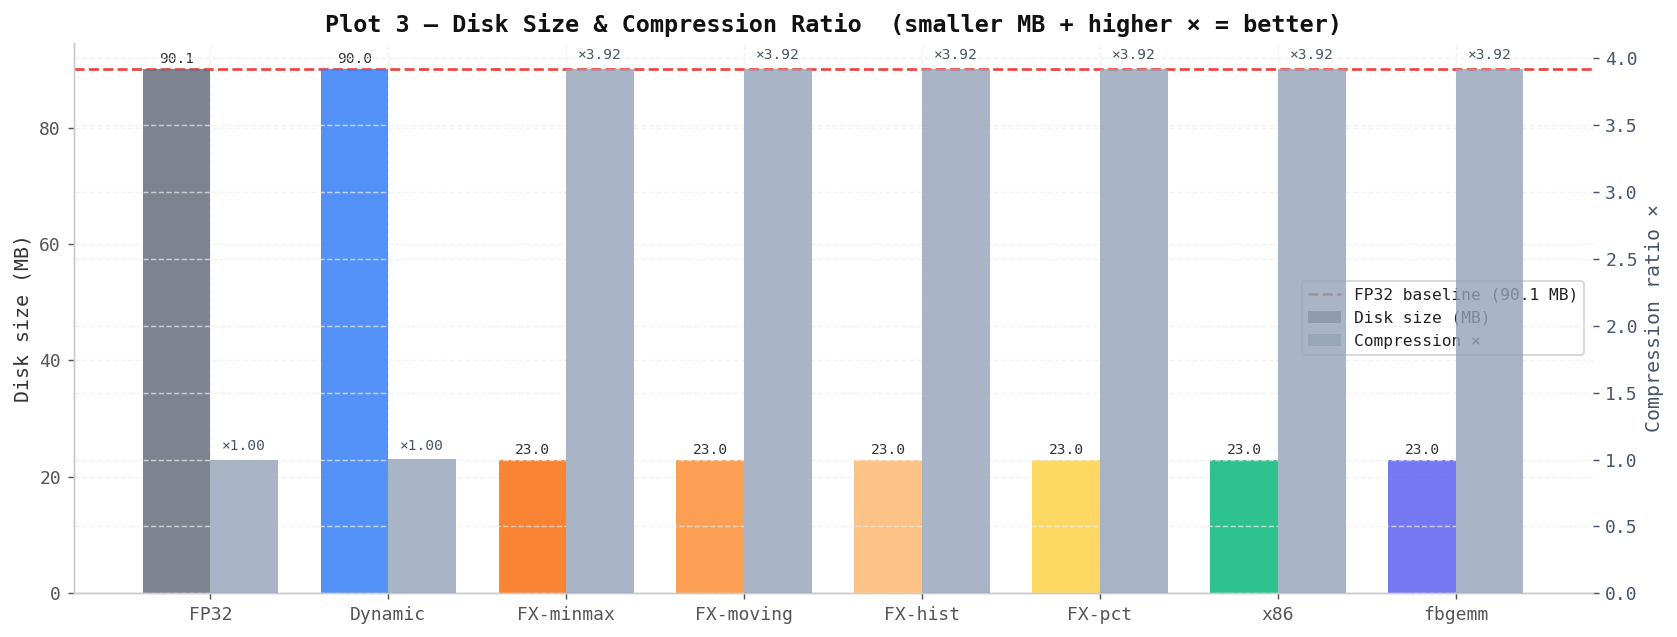

✓ Plot 3 saved → plot3_disk_compression.png


In [80]:
# %% — Plot 3: Disk Size + Compression Ratio (twin-axis grouped bar)
fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()
ax2.set_facecolor("white")

x = np.arange(len(results))
w = 0.38
bars1 = ax1.bar(x - w/2, disks,  w, color=COLORS,   alpha=BAR_ALPHA, label="Disk size (MB)", zorder=3)
bars2 = ax2.bar(x + w/2, comprs, w, color="#94A3B8", alpha=0.8,       label="Compression ×", zorder=3)
ax1.axhline(BASELINE_DISK, color="#EF4444", lw=1.5, ls="--",
            label=f"FP32 baseline ({BASELINE_DISK:.1f} MB)")

for bar, d in zip(bars1, disks):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{d:.1f}", ha="center", va="bottom", fontsize=8, color="#333")
for bar, c in zip(bars2, comprs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f"×{c:.2f}", ha="center", va="bottom", fontsize=8, color="#475569")

short = ["FP32","Dynamic","FX-minmax","FX-moving","FX-hist","FX-pct","x86","fbgemm"]
ax1.set_xticks(x); ax1.set_xticklabels(short)
ax1.set_ylabel("Disk size (MB)")
ax2.set_ylabel("Compression ratio ×", color="#475569")
ax2.tick_params(axis="y", colors="#475569")
ax2.spines["right"].set_color("#CCCCCC")

lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, fontsize=9)
ax1.set_title("Plot 3 — Disk Size & Compression Ratio  (smaller MB + higher × = better)")
plt.tight_layout()
plt.savefig("__1__PTQ_plots/plot3_disk_compression.png")
plt.show()
print("✓ Plot 3 saved → plot3_disk_compression.png")

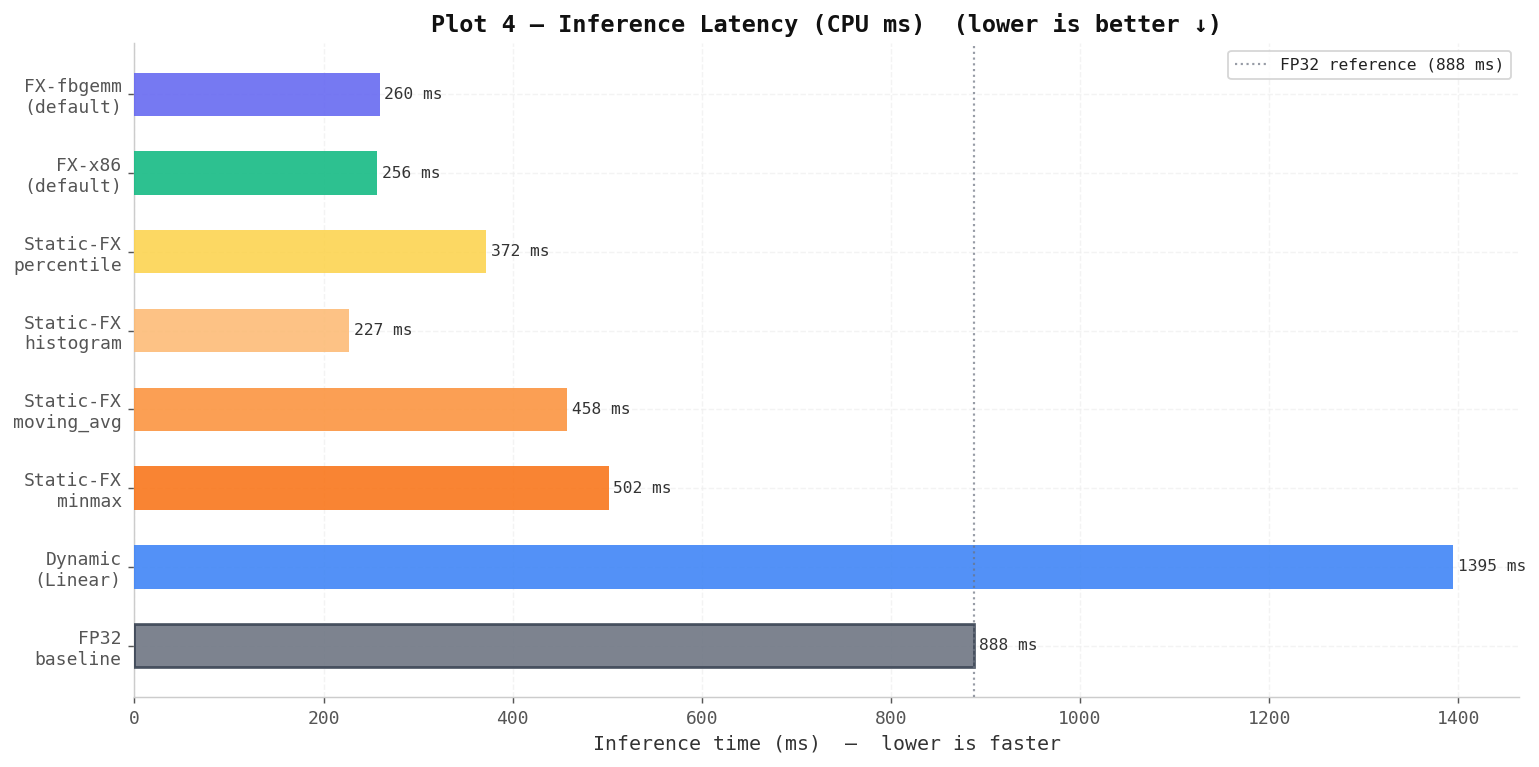

✓ Plot 4 saved → plot4_latency.png


In [81]:
# %% — Plot 4: Inference Latency (CPU ms)
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(labels, cpu_ms, color=COLORS, alpha=BAR_ALPHA, height=0.55, zorder=3)
bars[0].set_edgecolor("#374151"); bars[0].set_linewidth(1.5)

ax.axvline(BASELINE_CPU, color="#6B7280", lw=1.2, ls=":", alpha=0.7, zorder=4,
           label=f"FP32 reference ({BASELINE_CPU:.0f} ms)")

for bar, ms in zip(bars, cpu_ms):
    ax.text(ms + 5, bar.get_y() + bar.get_height() / 2,
            f"{ms:.0f} ms", va="center", ha="left", fontsize=9, color="#333")

ax.set_xlabel("Inference time (ms)  —  lower is faster")
ax.set_title("Plot 4 — Inference Latency (CPU ms)  (lower is better ↓)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("__1__PTQ_plots/plot4_latency.png")
plt.show()
print("✓ Plot 4 saved → plot4_latency.png")

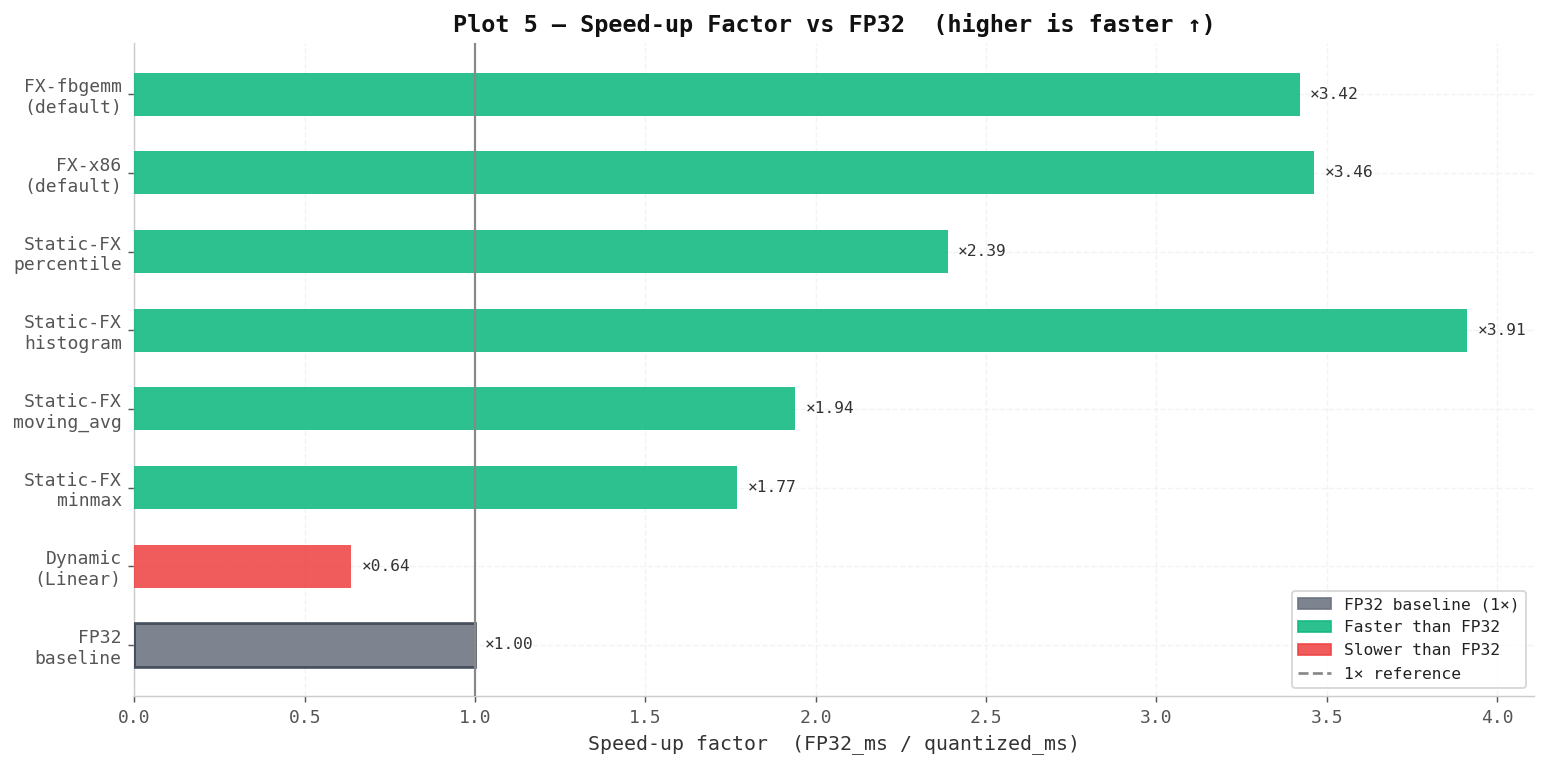

✓ Plot 5 saved → plot5_speedup.png


In [82]:
# %% — Plot 5: Speed-up Factor vs Baseline
fig, ax = plt.subplots(figsize=(12, 6))

su_colors = [COLORS[0]] + ["#10B981" if s >= 1 else "#EF4444" for s in speedups[1:]]
bars = ax.barh(labels, speedups, color=su_colors, alpha=BAR_ALPHA, height=0.55, zorder=3)
bars[0].set_edgecolor("#374151"); bars[0].set_linewidth(1.5)
ax.axvline(1.0, color="#888", lw=1.2, zorder=4, label="1× = FP32 baseline")

for bar, s in zip(bars, speedups):
    ax.text(s + 0.03, bar.get_y() + bar.get_height() / 2,
            f"×{s:.2f}", va="center", ha="left", fontsize=9, color="#333")

gray_p  = mpatches.Patch(color=COLORS[0], alpha=BAR_ALPHA, label="FP32 baseline (1×)")
green_p = mpatches.Patch(color="#10B981", alpha=BAR_ALPHA, label="Faster than FP32")
red_p   = mpatches.Patch(color="#EF4444", alpha=BAR_ALPHA, label="Slower than FP32")
ax.legend(handles=[gray_p, green_p, red_p,
                   Line2D([0],[0], color="#888", ls="--", label="1× reference")],
          fontsize=9)
ax.set_xlabel("Speed-up factor  (FP32_ms / quantized_ms)")
ax.set_title("Plot 5 — Speed-up Factor vs FP32  (higher is faster ↑)")
plt.tight_layout()
plt.savefig("__1__PTQ_plots/plot5_speedup.png")
plt.show()
print("✓ Plot 5 saved → plot5_speedup.png")

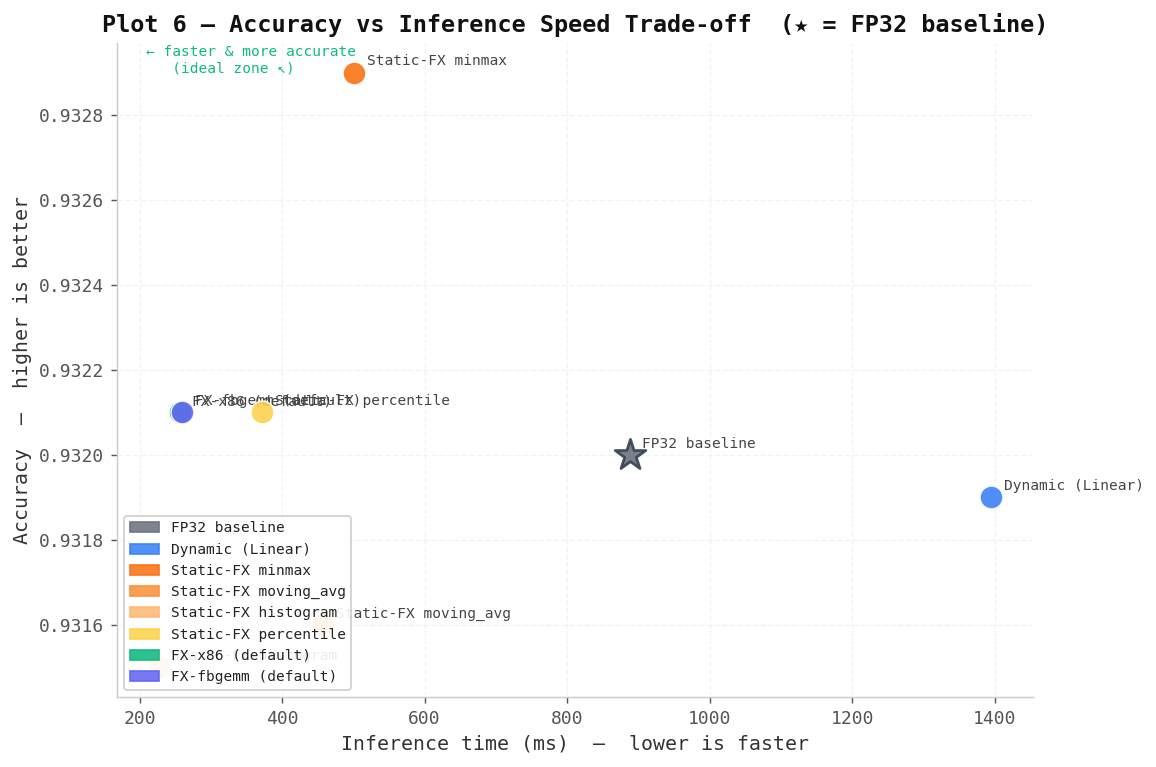

✓ Plot 6 saved → plot6_acc_vs_speed.png


In [83]:
# %% — Plot 6: Accuracy vs Speed Trade-off (scatter)
fig, ax = plt.subplots(figsize=(9, 6))

for ms, acc, col, lbl, i in zip(cpu_ms, accs, COLORS, labels, range(len(results))):
    marker = "*" if i == 0 else "o"
    size   = 320 if i == 0 else 160
    ax.scatter(ms, acc, s=size, color=col, alpha=0.9, zorder=4,
               edgecolors="white" if i > 0 else "#374151",
               lw=0.8 if i > 0 else 1.5, marker=marker)
    ax.annotate(lbl.replace("\n", " "), (ms, acc),
                textcoords="offset points", xytext=(7, 4),
                fontsize=8, color="#444")

ax.annotate("← faster & more accurate\n   (ideal zone ↖)",
            xy=(min(cpu_ms) * 0.92, max(accs)),
            fontsize=8, color="#10B981")

handles = [mpatches.Patch(color=c, label=l.replace("\n"," "), alpha=BAR_ALPHA)
           for c, l in zip(COLORS, labels)]
ax.legend(handles=handles, fontsize=8, loc="lower left", framealpha=0.9)
ax.set_xlabel("Inference time (ms)  —  lower is faster")
ax.set_ylabel("Accuracy  —  higher is better")
ax.set_title("Plot 6 — Accuracy vs Inference Speed Trade-off  (★ = FP32 baseline)")
plt.tight_layout()
plt.savefig("__1__PTQ_plots/plot6_acc_vs_speed.png")
plt.show()
print("✓ Plot 6 saved → plot6_acc_vs_speed.png")

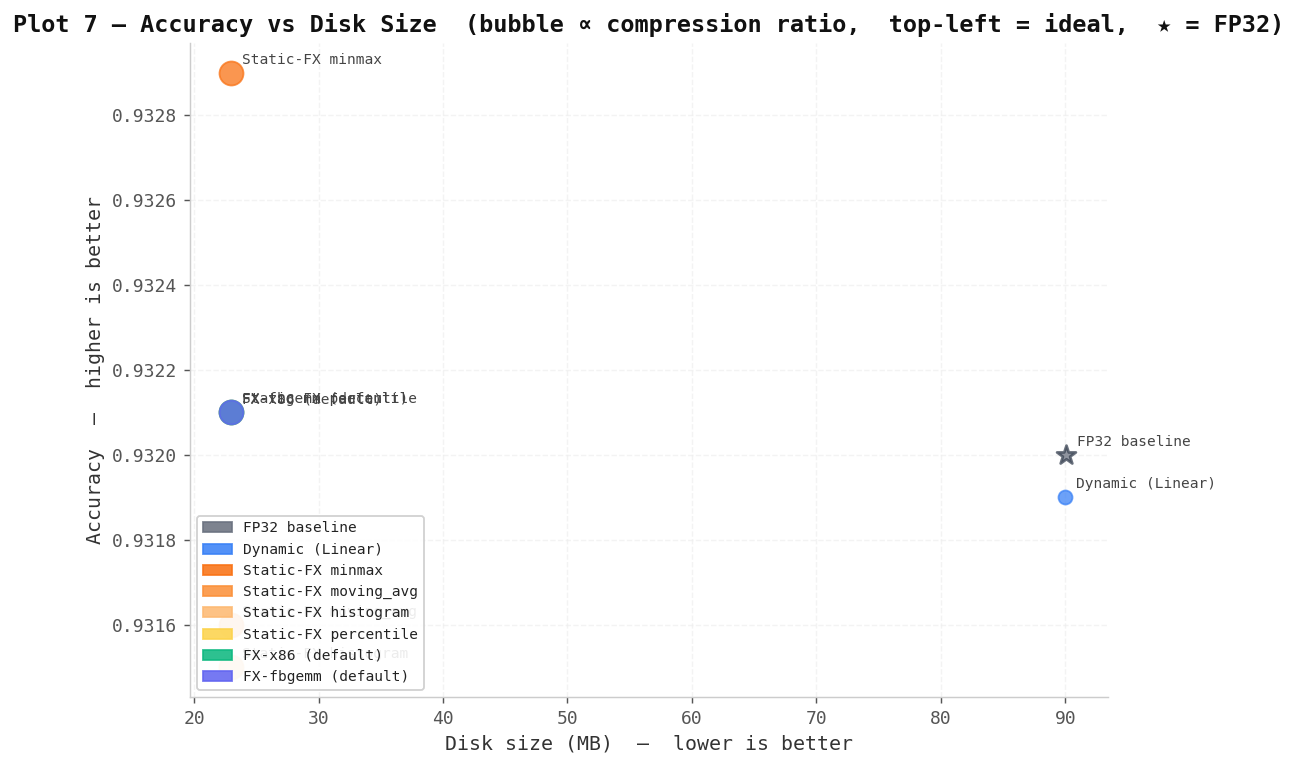

✓ Plot 7 saved → plot7_acc_vs_disk.png


In [84]:
# %% — Plot 7: Accuracy vs Disk Size (bubble = compression ratio)
fig, ax = plt.subplots(figsize=(9, 6))

for disk, acc, col, lbl, c, i in zip(disks, accs, COLORS, labels, comprs, range(len(results))):
    size   = max(c * 45, 60)
    marker = "*" if i == 0 else "o"
    size   = size * 2 if i == 0 else size
    ax.scatter(disk, acc, s=size, color=col, alpha=0.75, zorder=4,
               edgecolors="#374151" if i == 0 else col, lw=1.5 if i == 0 else 1.0,
               marker=marker)
    ax.annotate(lbl.replace("\n", " "), (disk, acc),
                textcoords="offset points", xytext=(6, 5),
                fontsize=8, color="#444")

handles = [mpatches.Patch(color=c, label=l.replace("\n"," "), alpha=BAR_ALPHA)
           for c, l in zip(COLORS, labels)]
ax.legend(handles=handles, fontsize=8, loc="lower left", framealpha=0.9)
ax.set_xlabel("Disk size (MB)  —  lower is better")
ax.set_ylabel("Accuracy  —  higher is better")
ax.set_title("Plot 7 — Accuracy vs Disk Size  (bubble ∝ compression ratio,  top-left = ideal,  ★ = FP32)")
plt.tight_layout()
plt.savefig("__1__PTQ_plots/plot7_acc_vs_disk.png")
plt.show()
print("✓ Plot 7 saved → plot7_acc_vs_disk.png")

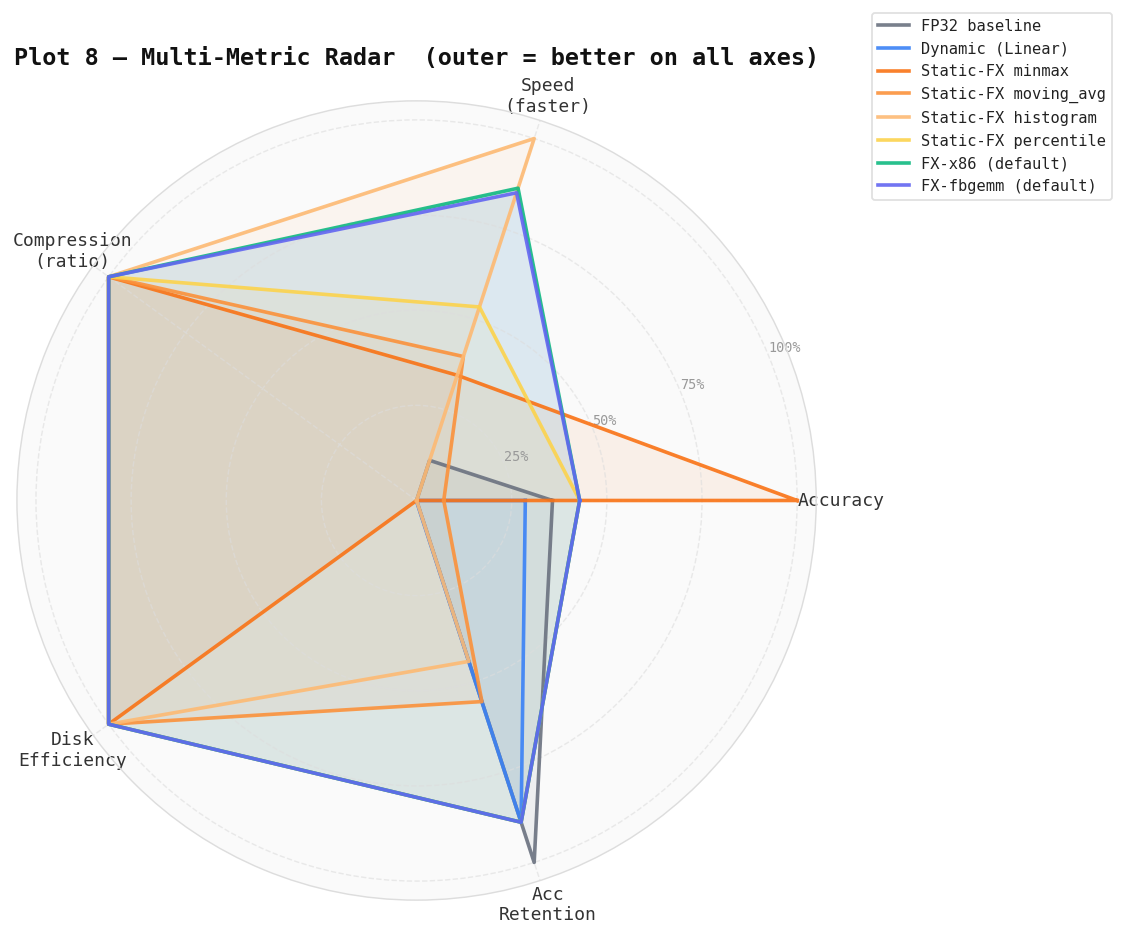

✓ Plot 8 saved → plot8_radar.png


In [85]:
# %% — Plot 8: Radar / Spider Chart
def normalize(vals, invert=False):
    mn, mx = min(vals), max(vals)
    if mx == mn:
        return [0.5] * len(vals)
    n = [(v - mn) / (mx - mn) for v in vals]
    return [1 - x for x in n] if invert else n

categories = ["Accuracy", "Speed\n(faster)", "Compression\n(ratio)",
              "Disk\nEfficiency", "Acc\nRetention"]
N_cat  = len(categories)
angles = np.linspace(0, 2 * np.pi, N_cat, endpoint=False).tolist()
angles += angles[:1]

norm_acc   = normalize(accs)
norm_spd   = normalize(speedups)
norm_compr = normalize(comprs)
norm_disk  = normalize(disks, invert=True)
norm_drop  = normalize([-abs(d) for d in drops])

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
fig.patch.set_facecolor("white")
ax.set_facecolor("#FAFAFA")

for i, (col, lbl) in enumerate(zip(COLORS, labels)):
    vals = [norm_acc[i], norm_spd[i], norm_compr[i], norm_disk[i], norm_drop[i]]
    vals += vals[:1]
    ax.plot(angles, vals, color=col, lw=2, alpha=0.9, label=lbl.replace("\n", " "))
    ax.fill(angles, vals, color=col, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10, color="#333")
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=7.5, color="#999")
ax.spines["polar"].set_color("#DDDDDD")
ax.grid(color="#DDDDDD", linestyle="--", alpha=0.6)

ax.legend(fontsize=8.5, loc="upper right",
          bbox_to_anchor=(1.38, 1.12), framealpha=0.9,
          edgecolor="#DDD")
ax.set_title("Plot 8 — Multi-Metric Radar  (outer = better on all axes)",
             fontsize=13, fontweight="bold", pad=20, color="#111")
plt.tight_layout()
plt.savefig("__1__PTQ_plots/plot8_radar.png")
plt.show()
print("✓ Plot 8 saved → plot8_radar.png")

In [86]:
# %% — Summary Table
print(f"\n{'='*92}")
print(f"  {'Backend':<22} {'Observer':<24} {'Acc':>7} {'Drop':>8} "
      f"{'Disk MB':>9} {'Compr':>7} {'CPU ms':>9} {'Speedup':>8}")
print(f"{'─'*92}")
for r, su in zip(results, speedups):
    sign = "+" if r["drop"] > 0 else ""
    print(f"  {r['backend']:<22} {r['observer']:<24} "
          f"{r['acc']:>7.4f} {sign}{r['drop']:>7.4f} "
          f"{r['disk']:>9.2f} {r['compr']:>7.3f}× "
          f"{r['cpu']:>9.1f} {su:>7.2f}×")
print(f"{'='*92}")
print(f"\n  ✓ All 8 plots saved (plot1_accuracy.png … plot8_radar.png)")
print(f"  Best overall: static_fx | observer=minmax | acc=0.9329 | ×3.92 compression")


  Backend                Observer                     Acc     Drop   Disk MB   Compr    CPU ms  Speedup
────────────────────────────────────────────────────────────────────────────────────────────
  FP32 baseline          —  (no quantization)      0.9320  0.0000     90.05   1.000×     887.9    1.00×
  dynamic                per_channel_affine        0.9319 + 0.0001     89.99   1.001×    1394.8    0.64×
  static_fx              minmax                    0.9329 -0.0009     22.99   3.917×     501.6    1.77×
  static_fx              moving_avg                0.9316 + 0.0004     22.99   3.917×     457.8    1.94×
  static_fx              histogram                 0.9315 + 0.0005     22.99   3.917×     226.9    3.91×
  static_fx              percentile                0.9321 -0.0001     22.99   3.917×     371.8    2.39×
  fx_static_x86          default(x86)              0.9321 -0.0001     22.99   3.917×     256.4    3.46×
  fx_static_fbgemm       default(fbgemm)           0.9321 -0.0001     2